# Deep Reinforcement Learning

 Reinforcement Learning (RL) is an approach wherein an agent learns to make sequential decisions by interacting with an environment. The objective is for the agent to maximize the cumulative reward it receives over time.
 The agent goes through this process by repeatedly evaluating the consequences of its actions, trying to select actions that lead to better outcomes.

To do this, we will use Gym, an platform for developing and comparing reinforcement learning algorithms. Gym provides an interface for interacting with different environments, it accepts actions from agents and plays them out in an environment, providing rewards.


## Environment

We will be using `CartPole` environment from gym's library for this assignment.  In this environment, a pole is attached by an un-actuated joint to a cart, which moves along a frictionless track. The pendulum is placed upright on the cart and the goal is to balance the pole by applying forces in the left and right direction on the cart.

You can use the code below to run an instance of a random agent in this environment and see the results.

In [2]:
# Contributors: Kian Ghassemi, Ayeen Poostforoushan, Nima Moazzen

In [3]:
from IPython.display import HTML
from base64 import b64encode

def show_video(path):
    mp4 = open(path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

In [4]:
#import cv2
import gym
import imageio
import numpy as np
from gym import spaces

Additionally, Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


We use `gym.make()` to make an instance of a certain environemtn. We can then use `.step()` method which accepts an action as input and performs it. Before that we reset the environment to its initial state by using `.reset()` method.

We use `gym.make()` to make an instance of a certain environemtn. We can then use `.step()` method which accepts an action as input and performs it. Before that we reset the environment to its initial state by using `.reset()` method.

/Users/paulboehmer/Documents/Teamprojekt/teamproject_26_dreamer/venv/lib/python3.14/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/Users/paulboehmer/Documents/Teamprojekt/teamproject_26_dreamer/venv/lib/python3.14/site-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


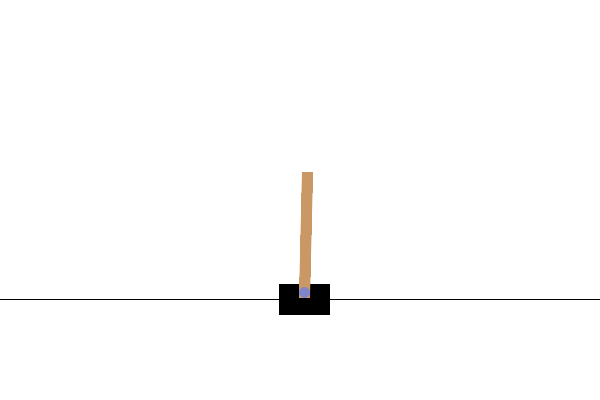

In [5]:
from IPython.display import Image, display

env_name = "CartPole-v1"

try:
    render_env = gym.make(env_name, render_mode="rgb_array")
    use_legacy_render = False
except TypeError:
    render_env = gym.make(env_name)
    use_legacy_render = True

def unpack_reset(reset_result):
    if isinstance(reset_result, tuple):
        observation, info = reset_result
        return observation
    return reset_result

def unpack_step(step_result):
    if len(step_result) == 5:
        observation, reward, terminated, truncated, info = step_result
        done = terminated or truncated
    else:
        observation, reward, done, info = step_result
    return observation, reward, done

def render_frame(env, use_legacy_render):
    if use_legacy_render:
        return env.render(mode="rgb_array")
    return env.render()

frames = []
observation = unpack_reset(render_env.reset())
done = False

for _ in range(500):
    frames.append(render_frame(render_env, use_legacy_render))
    action = render_env.action_space.sample()
    observation, reward, done = unpack_step(render_env.step(action))

    if done: 
        observation = unpack_reset(render_env.reset())
        done = False

render_env.close()
gif_path = "./cartpole.gif"
imageio.mimsave(gif_path, frames, fps=30)
display(Image(filename=gif_path))

As you can see, the cart fails to keep the balance of the pole. In the next section we will train an agent to learn how to perform this task.

## Algorithm
We will be using A2C algorithm.

Advantage Actor-Critic (A2C) is a reinforcement learning algorithm.
It consists of an actor (which predicts the best action based on the current state) and a critic (which estimates the state's value function to measure expected future rewards).

We will implement this together step by step.




In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions.categorical import Categorical
import numpy as np
import gym
from collections import deque
from tqdm import tqdm

## Neural Network

Here we design a simple feed forward model to embed the observation from the environment to a hidden layer. We then use two fully connected layers on top of the hidden layer, to predict the next action and estimate the value of current state. This acts as both actor, and critic.

You need to implement the convolutional neural network.


In [7]:
class ActorCritic(nn.Module):
    def __init__(self, hidden_size, num_outputs):
        super(ActorCritic, self).__init__()
        # TODO: define your model here
        self.hidden_layer = nn.Linear(4, hidden_size)
        # Actor:
        self.actor_layer = nn.Linear(hidden_size, num_outputs)
        # Critic:
        self.critic_layer = nn.Linear(hidden_size, 1)


    def forward(self, x):
        # compute result of hidden layer
        x = F.relu(self.hidden_layer(x))
        action_probs = F.softmax(self.actor_layer(x), dim=-1)
        value = self.critic_layer(x)
        return action_probs, value


## A2C

The A2C algorithm aims to jointly train both the actor and the critic to improve the policy. It does this by updating the parameters
of the actor to increase the likelihood of good actions and updating the parameters
of the critic to better estimate the value function.

In each iteration A2C plays the until it ends. During this time it records log probabality of actions, rewards, and predicted values in each step. These values will be used to update the model at the end of this trajectory.

The actor is updated using the objective below:

$$ L_{\text{actor}} = -\log \pi(a|s;\theta) \times A(s, a) $$
Where advantage is calculated as:
$$A(s, a) = Q(s, a) - V(s) $$

Namely the function $Q(s,a)$ is the estimated value of taking action
$a$
 in state
$s$.
$V(s)$ is the predicted value of our critic.

This loss function aims to improve the probability of playing actions that result in higher rewards.

As for the critic the loss function is defined as a simple mean square loss between actual value of an state and the predicted one:

$$ L_{\text{critic}} = \frac{1}{2} ( R - V(s))^2 $$

In [8]:
class A2CAgent:
    def __init__(self, env, num_episodes=1000, max_steps=500, gamma=0.99, lr=1e-3, hidden_size=256):
        self.env = env
        self.num_episodes = int(num_episodes)
        self.max_steps = max_steps
        self.gamma = gamma
        self.lr = lr
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # define your actor critic network, its optimzer and the loss function
        self.policy_net = ActorCritic(hidden_size, env.action_space.n).to(self.device)
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=self.lr)
        self.critic_loss = nn.MSELoss()

    def choose_action(self, state):
        # choose an action by sampling from the policy distribution
        state = torch.FloatTensor(state).to(self.device)
        action_probs, _ = self.policy_net(state)
        action = torch.multinomial(action_probs, 1).item()
        return action

    def compute_returns(self, rewards):
        # calculate the discounted rewards used in the training process
        R = 0
        returns = []
        for r in reversed(rewards):
            R *= self.gamma
            R += r
            returns.insert(0, R)
        returns = torch.tensor(returns).to(self.device)
        return returns

    def train(self):
        episode_rewards = np.array([])
        with tqdm(range(self.num_episodes)) as pbar:
            for episode in pbar:
                # Implement the training loop
                state = self.env.reset()
                episode_reward = 0
                values = []
                rewards = []
                logits = []

                for step in range(self.max_steps):
                    # first you need to gather log probabilities, state values and rewards from a trajectory
                    # update the 'episode_reward'
                    state = torch.FloatTensor(state).to(self.device)
                    action_probs, value = self.policy_net(state)
                    action = torch.multinomial(action_probs, 1).item()

                    next_state, reward, done, _ = self.env.step(action)
                    new_probs = torch.log(action_probs[action])
                    values.append(value)
                    rewards.append(reward)
                    logits.append(new_probs)

                    episode_reward += reward
                    state = next_state
                    #terminate state
                    if done:
                        break


                episode_rewards = np.append(episode_rewards, episode_reward)

                # calculate the discounted rewards
                returns = self.compute_returns(rewards)

                # calculate advantage
                values = torch.cat(values)
                logits = torch.stack(logits)
                advantage = returns - values

                # compute actor and critic losses
                actorLoss = -(logits * advantage.detach()).mean()
                criticLoss = self.critic_loss(values, returns)
                lossEval = actorLoss + criticLoss

                self.optimizer.zero_grad()
                lossEval.backward()
                self.optimizer.step()

                pbar.set_description(f"Episode {episode}, Reward: {np.mean(episode_reward)}")

        self.env.close()
        return episode_rewards

Define the model and set hyperparameters.

In [9]:
env = gym.make('CartPole-v1')
num_episodes = 1000
max_steps = 500
lr = 1e-3
hidden_size = 256

a2c_model =  A2CAgent(env, num_episodes=num_episodes, max_steps=max_steps, lr=lr, hidden_size=hidden_size)

Train the model.

In [10]:
rewards = a2c_model.train()

Episode 999, Reward: 500.0: 100%|██████████| 1000/1000 [00:46<00:00, 21.56it/s]


## Evaluation

Use the `choose_action` method of the trained agent to evaluate its performance.

/Users/paulboehmer/Documents/Teamprojekt/teamproject_26_dreamer/venv/lib/python3.14/site-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


Episode Reward: 500.0


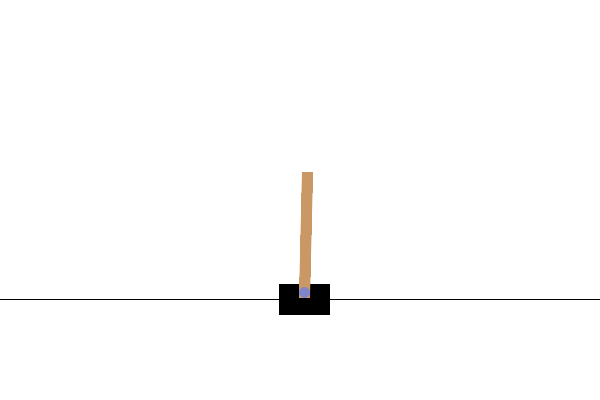

In [11]:
import imageio
from IPython.display import Image, display

try:
    render_env = gym.make("CartPole-v1", render_mode="rgb_array")
    use_legacy_render = False
except TypeError:
    render_env = gym.make("CartPole-v1")
    use_legacy_render = True

def unpack_reset(reset_result):
    if isinstance(reset_result, tuple):
        observation, info = reset_result
        return observation
    return reset_result

def unpack_step(step_result):
    if len(step_result) == 5:
        observation, reward, terminated, truncated, info = step_result
        done = terminated or truncated
    else:
        observation, reward, done, info = step_result
    return observation, reward, done

def render_frame(env, use_legacy_render):
    if use_legacy_render:
        return env.render(mode="rgb_array")
    return env.render()

def record_episode(agent, env, use_legacy_render, output_path="a2c_cartpole.gif"):
    frames = []
    observation = unpack_reset(env.reset())
    episode_reward = 0
    done = False
    device = next(agent.policy_net.parameters()).device

    while not done:
        frames.append(render_frame(env, use_legacy_render))
        observation_tensor = torch.tensor(
            observation, dtype=torch.float32
        ).unsqueeze(0).to(device)

        with torch.no_grad():
            action_probs, _ = agent.policy_net(observation_tensor)

        action = action_probs.argmax(dim=1).item()
        observation, reward, done = unpack_step(env.step(action))
        episode_reward += reward

    imageio.mimsave(output_path, frames, fps=30)
    return output_path, episode_reward

gif_path, episode_reward = record_episode(a2c_model, render_env, use_legacy_render)
render_env.close()

print(f"Episode Reward: {episode_reward}")
display(Image(filename=gif_path))